# Introduction

In this Quiz #1 you need to perform exploratory data analysis (EDA) and preprocessing using "Census Income" dataset. The dataset is tabular data which has several missing value in some variables. Moreover, you may need to adjust the name of variables (if needed).

To guide you through this task, some code has beed provided including, download the data, loading the data, and metadata inspection.

# Load Data and Inspect Metadata

In [ ]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [ ]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [ ]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Data Size
df.shape

(48842, 15)

In [ ]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Part 1 - Data Loading dan Data Imputation

## Task 1 (5 points)
1.   Do inspection to get the information about dataset
2.   **Which variable(s)** has **missing values**? **How many is it**?



In [ ]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
df.info()
missing_values = df.isnull().sum()

print("\nMissing values for each variable:")
print(missing_values)

print("\nVariables with missing values:")
print(missing_values[missing_values > 0])

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB

Missing values for each variable:
age                 0
workclass         963
fnlwgt              0
education           0
ed

## Task 2 (5 points)
1. Perform data imputation on missing values.
2. Verified the missing values for each variable. Is it still there?

In [ ]:
# Answer task 2 using this cell
# You can add another cell after this cell if needed
df = df.fillna('Others')
missing_values = df.isnull().sum()

print("Missing values for each variable:")
print(missing_values)

print("\nTotal missing values:")
print(missing_values.sum())

Missing values for each variable:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Total missing values:
0


## Task 3 (10 points)
Do inspection to all the quantitative variables (features). If you found an **inappropriate value(s)**, replace it with '**Others**'. Also, if you found any typos value(s), **fix the typos**.

In [ ]:
# Answer task 3 using this cell
# You can add another cell after this cell if needed
quantitative_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

df[quantitative_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
for col in df.columns:
    print(f"\n=== {col} ===")
    print(df[col].unique())


=== age ===
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89]

=== workclass ===
<ArrowStringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                '?',
     'Self-emp-inc',      'Without-pay',     'Never-worked',
           'Others']
Length: 10, dtype: str

=== fnlwgt ===
[ 77516  83311 215646 ... 173449  89686 350977]

=== education ===
<ArrowStringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',    'Assoc-voc',
      '7th-8th',    'Doctorate',  'Prof-school',      '5th-6th',
         '10th',      '1st-4th',    'Preschool',         '12th']
Length: 16, dtype: str

=== education-num ===
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

=== marital-status ===
<ArrowStringA

In [ ]:
for col in quantitative_cols:
    print(f"\n=== {col} ===")
    print("Min :", df[col].min())
    print("Max :", df[col].max())


=== age ===
Min : 17
Max : 90

=== fnlwgt ===
Min : 12285
Max : 1490400

=== education-num ===
Min : 1
Max : 16

=== capital-gain ===
Min : 0
Max : 99999

=== capital-loss ===
Min : 0
Max : 4356

=== hours-per-week ===
Min : 1
Max : 99


In [ ]:
df['workclass'] = df['workclass'].replace('?', 'Others')

df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

print("Unique values - workclass:")
print(df['workclass'].unique())

print("\nUnique values - income:")
print(df['income'].unique())

Unique values - workclass:
<ArrowStringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',           'Others',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

Unique values - income:
<ArrowStringArray>
['<=50K', '>50K']
Length: 2, dtype: str


# Part 2 - Visual Inspection



## Task 1 - Data Visualization (20 points)
Do inspection on this following variabels,
1. On the 'age' by using a histogram
2. On the 'education' using a barchart
3. On the 'income' to 'hours_per_week' by using a boxplot (grouped by income)
4. On the 'age' to 'capital-gain' and 'capital-loss' using lineplot (lineplot with multiple x-data)

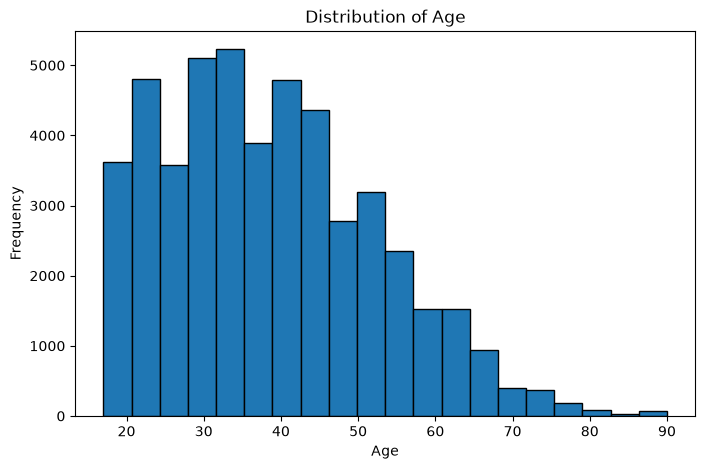

In [ ]:
# Answer 1.1 - Histrogram
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=20, edgecolor='black')

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

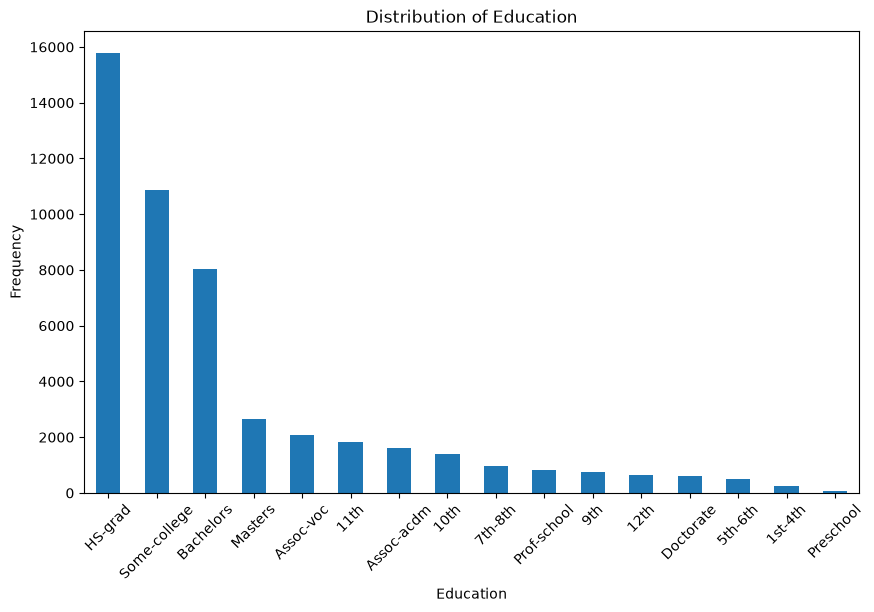

In [ ]:
# Answer 1.2 - Barchart
plt.figure(figsize=(10, 6))

education_counts = df['education'].value_counts()

education_counts.plot(kind='bar')

plt.title('Distribution of Education')
plt.xlabel('Education')
plt.ylabel('Frequency')

plt.xticks(rotation=45)
plt.show()

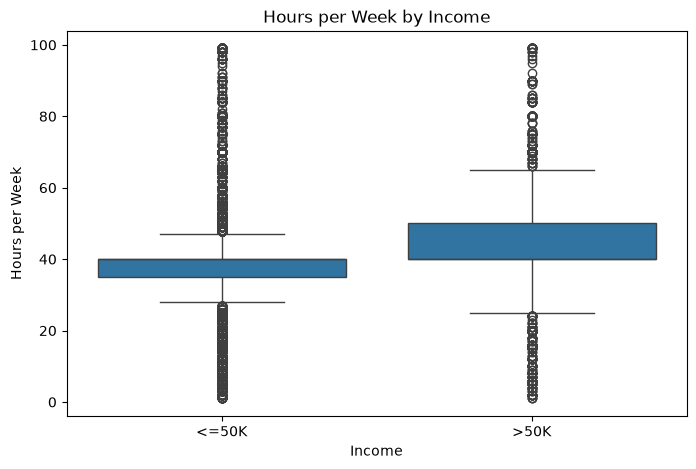

In [ ]:
# Answer 1.3 - Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Hours per Week by Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')

plt.show()

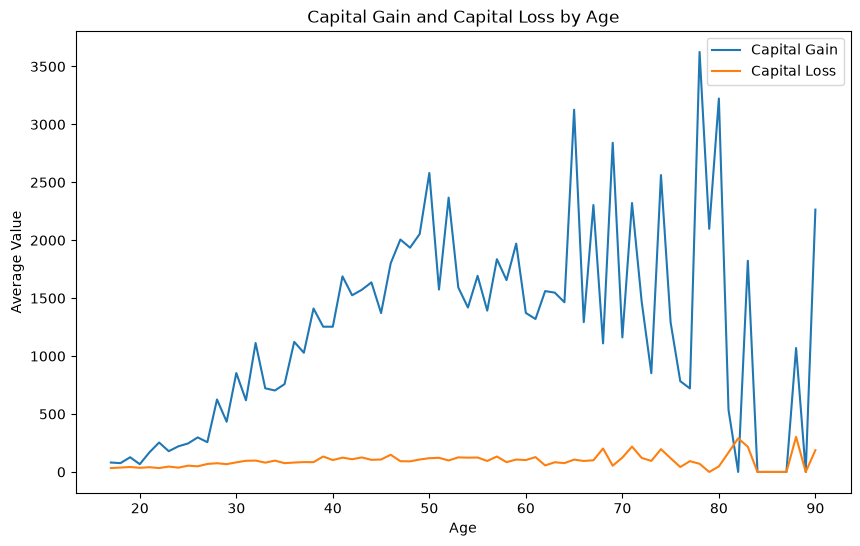

In [ ]:
# Answer 1.4 - Lineplot
age_income = df.groupby('age')[['capital-gain', 'capital-loss']].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    age_income.index,
    age_income['capital-gain'],
    label='Capital Gain'
)

plt.plot(
    age_income.index,
    age_income['capital-loss'],
    label='Capital Loss'
)

plt.title('Capital Gain and Capital Loss by Age')
plt.xlabel('Age')
plt.ylabel('Average Value')

plt.legend()
plt.show()

## Task 2 - Visual Analysis (15 points)
1. What kind of distribution showed in 'age'?
2. If you find missing values in 'age', what kind of data impute method will you use? Why?
3. How many outliner for each category (group) in 'income' related to 'hour-per-week'? Which category has more outlier?

In [ ]:
# Answer with python comment like this -> inline comment

'''
  Or by using multiple
  line comments like this
'''

'\n  Or by using multiple\n  line comments like this\n'

1. Variabel age menunjukan distribusi right-skewed. Sebagian besar data terkonsentrasi pada usia muda hingga usia pertengahan, kemudian frekuensinya semakin menurun seiring bertambahnya usia sehingga membentuk ekor yang lebih panjang di sisi kanan

2. Jika terdapat missing value pada variable age, metoode yang digunakan adalah median imputation. Hal ini karena distribusi age terlihat miring ke kanan, sehingga median lebih sesuai dan tidak terlalu dipengaruhi oleh nilai ekstrem dibandingkan mean.

3.

In [ ]:
for income_group in df['income'].unique():

    data = df[df['income'] == income_group]['hours-per-week']

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outliers = data[
        (data < batas_bawah) |
        (data > batas_atas)
    ]

    print(f"Income: {income_group}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"Batas bawah: {batas_bawah}")
    print(f"Batas atas: {batas_atas}")
    print(f"Jumlah outlier: {len(outliers)}")
    print()

Income: <=50K
Q1: 35.0
Q3: 40.0
Batas bawah: 27.5
Batas atas: 47.5
Jumlah outlier: 11706

Income: >50K
Q1: 40.0
Q3: 50.0
Batas bawah: 25.0
Batas atas: 65.0
Jumlah outlier: 781



# Part 3 - Encoding in Categorical Variable

## Task 1 (5 points)
Do encoding process on 'Sex' and 'Income', while 'Income' is target variable.

In [ ]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

df['sex'] = df['sex'].map({
    'Female': 0,
    'Male': 1
})

df['income'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})

print("\nHasil encoding:")
print(df[['sex', 'income']].head())


Hasil encoding:
   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Part 4 - Correlation Analysis

## Task 1 (10 points)
1. Do correlation analysis on the following variabels: 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', and 'income' (encoded version from previous task)
2. Based on the result, what kind of information you get?

In [ ]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
correlation_cols = [
    'age',
    'education-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
    'income'
]

correlation_matrix = df[correlation_cols].corr()

print(correlation_matrix)

                     age  education-num  hours-per-week  capital-gain  \
age             1.000000       0.030940        0.071558      0.077229   
education-num   0.030940       1.000000        0.143689      0.125146   
hours-per-week  0.071558       0.143689        1.000000      0.082157   
capital-gain    0.077229       0.125146        0.082157      1.000000   
capital-loss    0.056944       0.080972        0.054467     -0.031441   
income          0.230369       0.332613        0.227687      0.223013   

                capital-loss    income  
age                 0.056944  0.230369  
education-num       0.080972  0.332613  
hours-per-week      0.054467  0.227687  
capital-gain       -0.031441  0.223013  
capital-loss        1.000000  0.147554  
income              0.147554  1.000000  


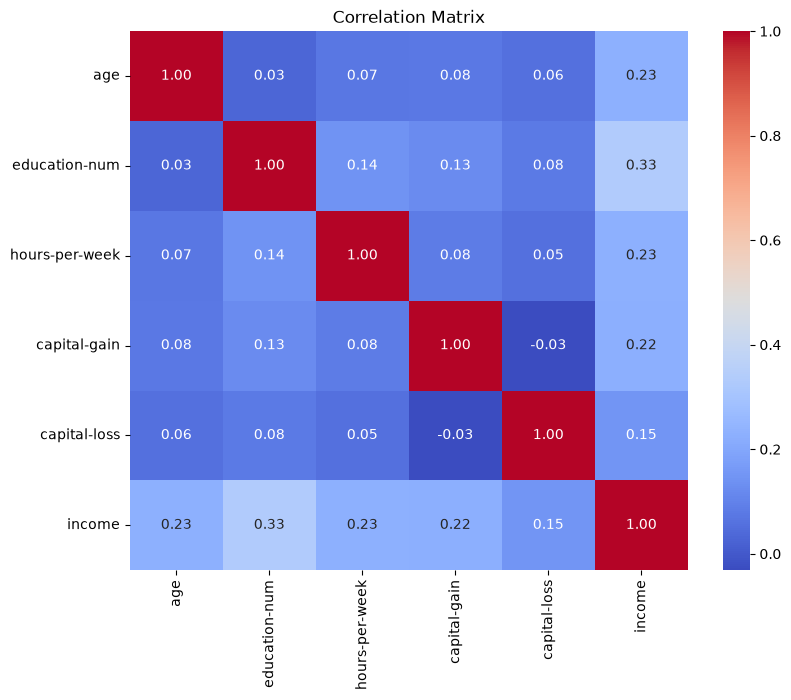

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Answer task 2 using this cell -> you can use multiple comments style too

'\nBerdasarkan hasil correlation analysis, seluruh variabel yang dianalisis\nmemiliki korelasi positif terhadap income.\n\nKorelasi tertinggi dengan income terdapat pada education-num, yaitu 0.33.\nSelanjutnya age dan hours-per-week memiliki korelasi sebesar 0.23,\ncapital-gain sebesar 0.22, dan capital-loss sebesar 0.15.\n\nSecara umum, hubungan antara variabel-variabel tersebut dengan income\ntergolong relatif lemah hingga sedang. Korelasi menunjukkan hubungan\nlinear antarvariabel dan tidak menunjukkan hubungan sebab-akibat.\n'

2. Berdasarkan hasil correlation analysis, seluruh variabel yang dianalisis memiliki korelasi positif terhadap income. Korelasi tertinggi terhadap income terdapat pada education-num dengan nilai 0.33, sedangkan korelasi terendah terdapat pada capital-loss dengan nilai 0.15. Variabel age dan hours-per-week memiliki nilai korelasi yang sama, yaitu 0.23, sedangkan capital-gain memiliki korelasi sebesar 0.22. Secara umum, nilai korelasi tersebut menunjukkan adanya hubungan positif tetapi relatif lemah hingga sedang antara variabel-variabel tersebut dengan income. Hasil ini menunjukkan bahwa erubahan pada variabel-variabel tersebut memiliki hubungan linear dengan income.

# Part 5 - Preprocessing on MNIST Dataset

In this part, you need to perform EDA and simple preprocessing on MNIST dataset. This dataset contain images of handwritten digit from 0 to 9. A pre configuration is provided to help you to load the data and inspect some images.

Hints:
1. You only need to use the **Test** set.
2. You need to perform to all of images in test set (10k images). You may need a function to complete this task (optional).

In [1]:
!pip install tensorflow

In [2]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


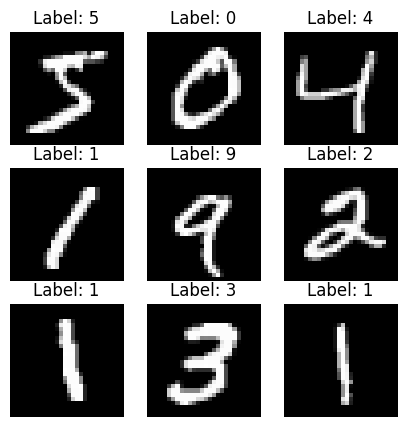

In [3]:
# Visual Inspection
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Task 1 (10 points)
1. Perform **upsampling** on the images to 32x32
2. Show the 5 sample of the result.


Hint: You need to store the result in an empty array. Replacing data to the  **X_test** cannot be done due to the shape of the array (10000, (28,28)). You need to create an array which match with the size of the new images.

In [4]:
# Answer task 1 using this cell
# You can add another cell after this cell if needed
from tensorflow.image import resize

X_test_upsampled = np.empty(
    (X_test.shape[0], 32, 32),
    dtype=np.float32
)

for i in range(X_test.shape[0]):
    X_test_upsampled[i] = resize(
        X_test[i][..., np.newaxis],
        (32, 32)
    ).numpy().squeeze()

print("Original shape :", X_test.shape)
print("Upsampled shape:", X_test_upsampled.shape)

Original shape : (10000, 28, 28)
Upsampled shape: (10000, 32, 32)


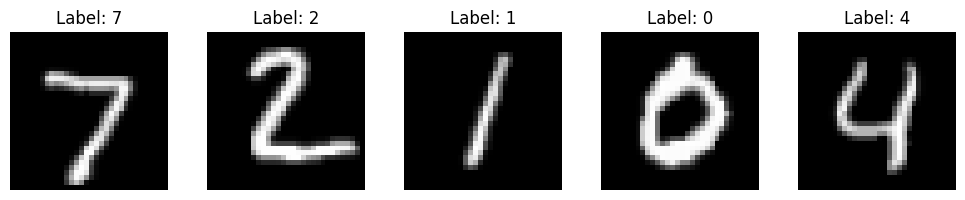

In [5]:
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Task 2 (10 points)
Perform normalization, so the pixel value will have a value in range of 0 until 1

In [6]:
# Answer task 2 using this cell
# You can add another cell after this cell if needed
X_test_normalized = X_test_upsampled / 255.0

print("Minimum pixel value:", X_test_normalized.min())
print("Maximum pixel value:", X_test_normalized.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Task 3 (10 points)
Transform / reshape the images into 1 dimensional array. Do it to the all images (after resizing and normalization).

Hint: You may need an empty array to store the result

In [7]:
# Answer task 3 using this cell
# You can add another cell after this cell if needed
X_test_reshaped = X_test_normalized.reshape(
    X_test_normalized.shape[0],
    32 * 32
)

print("Shape after reshape:", X_test_reshaped.shape)

Shape after reshape: (10000, 1024)
